

ASL Decoder Ring — Validation Protocol
=====================================
Validates the hypothesis that confusion matrix structure is a diagnostic
instrument for ASL model training regime (landmark-only, image-based, hybrid)
without requiring access to model weights, training data, or documentation.

Validation chain:
  Step 1 — Reference Topologies: Build landmark-pole reference (KNN on raw coordinates)
  Step 2 — Spearman Correlation: Quantify structural similarity across matrices
  Step 3 — Asymmetry Index: Directional signature stability across datasets
  Step 4 — Residual Decomposition: Separate geometric explanation from training signal
  Step 5 — Bootstrap Stability: Confirm cluster structure is not sampling artifact

Authors: asl_gemma4 project
Date: 2026-04-28
"""

In [ ]:
# --- Cell 1: Run this first ---
# %matplotlib inline


In [ ]:
# --- Cell 2: Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import networkx as nx
from itertools import combinations
import warnings
from IPython.display import display as ipy_display
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# =============================================================================
# DATA PATHS — update if running locally
# =============================================================================

In [ ]:
DRIVE_ROOT     = "/content/drive/MyDrive/ASL_Project"
OUTPUT_DIR     = os.path.join(DRIVE_ROOT, "validation_outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

LANDMARKS_RAW    = os.path.join(DRIVE_ROOT, "asl_landmarks_final.csv")
LM_DIST_ROBOFLOW = os.path.join(DRIVE_ROOT, "landmark_distances_roboflow.csv")
LM_DIST_ISL      = os.path.join(DRIVE_ROOT, "landmark_distances.csv")

print(f"Output directory: {OUTPUT_DIR}")
print(f"Files expected:")
for f in [LANDMARKS_RAW, LM_DIST_ROBOFLOW, LM_DIST_ISL]:
    exists = "✓" if os.path.exists(f) else "✗ NOT FOUND"
    print(f"  {exists}  {os.path.basename(f)}")


Output directory: /content/drive/MyDrive/ASL_Project/validation_outputs
Files expected:
  ✓  asl_landmarks_final.csv
  ✓  landmark_distances_roboflow.csv
  ✓  landmark_distances.csv


In [ ]:
# Gemma 4 confusion matrices (hardcoded from audit runs — source of truth)
LABELS = list('ABCDEFGHIKLMNOPQRSTUVWXY')  # 24 static letters (no J)

In [ ]:
# Roboflow audit matrix (simple prompt, temp=0.1, 1185 images)
GEMMA_ROBOFLOW = np.array([
    [12,1,2,0,1,1,0,0,0,0,0,5,0,0,1,1,0,0,11,0,0,0,0,0],
    [6,5,0,0,7,1,1,0,0,0,0,8,0,0,0,0,0,0,0,1,0,0,7,0],
    [0,0,60,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [15,0,0,2,0,0,1,0,43,2,0,1,0,0,0,0,0,0,0,2,0,0,0,0],
    [0,3,0,0,7,1,0,0,0,0,0,9,11,0,1,0,0,1,0,2,0,2,30,0],
    [4,1,1,0,11,0,0,0,0,0,4,0,0,0,1,0,0,0,0,0,0,3,7,0],
    [0,0,0,18,0,0,0,0,14,5,0,0,0,0,0,2,0,0,0,0,0,0,0,0],
    [2,17,1,2,16,1,0,1,3,0,0,6,0,0,0,1,0,0,0,0,0,7,5,0],
    [1,0,0,9,0,0,1,0,34,2,0,2,0,0,0,4,0,1,0,1,0,5,0,0],
    [3,4,3,7,9,2,1,0,1,2,0,4,0,0,0,1,0,1,0,0,1,2,2,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,40,0,0],
    [3,0,0,6,1,0,1,0,23,0,0,3,0,0,0,1,0,0,0,2,0,0,1,0],
    [11,2,1,0,2,1,1,0,0,0,0,8,0,0,1,0,0,2,9,1,0,1,2,0],
    [4,5,1,0,11,2,0,1,1,0,0,5,1,0,1,2,0,0,0,0,0,0,5,0],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,44,0,0,0,0,0,0,1,0,0],
    [1,0,0,28,0,1,2,1,5,5,1,18,0,0,0,2,0,0,0,1,0,1,2,0],
    [1,0,0,6,6,0,1,1,2,1,0,0,0,0,0,0,0,0,0,2,1,5,2,0],
    [5,1,0,0,7,1,1,0,1,0,0,5,3,0,0,0,0,1,0,0,0,10,6,0],
    [11,1,1,1,1,2,0,1,0,0,0,17,1,0,2,3,0,0,12,0,0,4,1,0],
    [0,0,0,17,0,0,2,0,11,1,0,3,0,0,0,0,0,0,0,3,0,0,0,0],
    [7,2,0,0,8,1,0,1,0,0,0,4,2,0,0,0,0,0,0,5,0,7,12,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0],
    [3,0,0,0,11,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4,16,0],
    [0,0,2,5,0,0,1,0,25,6,0,0,0,0,0,3,0,4,0,1,0,1,0,0],
])

In [ ]:
# ISL audit matrix (simple prompt, temp=0.1, 1185 images)
GEMMA_ISL = np.array([
    [9,3,1,0,1,0,0,0,0,0,0,5,0,0,0,2,0,0,12,1,0,0,1,0],
    [3,5,1,0,9,0,2,0,0,0,0,8,1,0,0,0,0,0,0,0,0,0,7,0],
    [0,0,59,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0],
    [18,0,0,3,0,0,0,0,37,0,0,1,0,0,0,2,0,0,0,4,0,0,1,0],
    [0,4,0,0,6,0,0,0,0,0,0,7,12,0,1,0,0,0,0,0,0,2,34,0],
    [2,1,0,0,11,0,0,0,0,0,2,3,1,0,1,0,0,0,0,1,0,3,6,0],
    [0,0,0,19,0,0,2,0,12,4,0,1,0,0,0,1,0,0,0,0,0,0,0,0],
    [4,8,0,2,15,2,0,0,0,2,0,7,2,0,0,0,0,0,0,0,0,6,14,0],
    [2,0,0,5,1,0,3,2,32,0,0,2,0,0,0,3,0,2,0,6,0,3,0,0],
    [1,7,1,5,6,4,0,1,0,3,1,6,0,1,0,0,0,0,1,0,0,2,5,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,41,0,0],
    [1,1,0,4,2,0,1,0,18,2,0,3,0,0,0,1,0,1,0,5,0,2,1,0],
    [11,4,3,0,2,0,1,0,0,0,0,6,0,0,0,0,0,0,8,3,0,1,1,0],
    [6,3,2,2,6,1,0,0,0,0,0,4,0,0,0,0,0,0,0,1,0,0,14,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,46,0,0,0,0,0,0,0,0,0],
    [2,1,0,23,1,3,5,1,9,5,0,7,0,0,0,1,0,0,0,3,0,7,0,0],
    [5,1,0,5,1,0,0,1,2,0,0,1,0,0,0,2,0,0,0,0,0,7,5,0],
    [5,1,0,0,9,0,2,0,2,0,0,4,3,0,0,0,0,0,0,1,0,5,4,0],
    [11,1,1,1,1,1,1,0,0,0,0,15,1,0,1,1,0,1,10,3,0,6,3,0],
    [0,0,0,15,0,0,1,0,10,1,0,4,1,0,0,2,0,0,0,3,0,0,0,0],
    [7,0,0,0,11,0,0,1,0,0,0,4,4,0,1,0,0,0,0,2,1,11,11,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,35,0,0],
    [3,1,0,0,13,0,0,0,0,0,0,0,0,0,1,0,0,2,0,0,0,1,12,0],
    [0,0,3,2,0,0,0,0,29,8,0,1,0,0,0,2,0,2,0,1,0,0,0,0],
])

=====================================
UTILITY: Row-normalize confusion matrix to error probability distributions
=====================================


In [ ]:
def row_normalize(matrix):
    """Convert count matrix to per-letter error probability distributions."""
    m = matrix.astype(float)
    row_sums = m.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid divide by zero
    return m / row_sums


# =====================================
STEP 1: Build Landmark-Pole Reference Topology
 KNN trained on raw 63-column MediaPipe coordinate data
# =====================================

In [ ]:
def build_landmark_reference(path, labels_to_use, n_neighbors=5, test_size=0.25,
                              n_bootstrap=1, random_state=42):
    """
    Train KNN on raw landmark coordinates, return confusion matrix.
    This is the clean landmark-pole reference — no pixels, pure geometry.
    """
    print("=" * 60)
    print("STEP 1: Building Landmark-Pole Reference Topology")
    print("=" * 60)

    df = pd.read_csv(path)

    # Drop motion signs and non-letter classes
    drop_labels = ['J', 'Z', 'del', 'space']
    df = df[~df['label'].isin(drop_labels)].copy()
    df = df[df['label'].isin(labels_to_use)].copy()

    print(f"Cleaned dataset: {len(df)} rows | {df['label'].nunique()} letters")
    print(f"Letter counts:\n{df['label'].value_counts().sort_index().to_string()}\n")

    feature_cols = [c for c in df.columns if c != 'label']
    X = df[feature_cols].values
    y = df['label'].values

    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=test_size, stratify=y_enc, random_state=random_state)

    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    acc = (y_pred == y_test).mean()
    print(f"KNN (k={n_neighbors}) test accuracy: {acc*100:.1f}%")
    print(f"Test set size: {len(y_test)} samples\n")

    cm = confusion_matrix(y_test, y_pred, labels=range(len(le.classes_)))
    cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

    # Reindex to match LABELS order
    cm_df = cm_df.reindex(index=labels_to_use, columns=labels_to_use, fill_value=0)

    print("Landmark reference confusion matrix built.")
    print(f"Letters covered: {list(cm_df.index)}\n")

    return cm_df.values, le.classes_



STEP 2: Vectorized Spearman Correlation
Measures structural similarity between confusion matrices

In [ ]:
def spearman_matrix_similarity(mat_a, mat_b, name_a, name_b, labels):
    """
    Flatten row-normalized confusion matrices to vectors,
    compute Spearman rank correlation.
    Preserves full asymmetric structure — K→V ≠ V→K.
    """
    norm_a = row_normalize(mat_a).flatten()
    norm_b = row_normalize(mat_b).flatten()

    rho, pval = spearmanr(norm_a, norm_b)
    return rho, pval


def run_spearman_comparisons(gemma_roboflow, gemma_isl, landmark_ref, labels):
    """
    Run full Spearman comparison battery.
    Key comparisons:
      1. Gemma-Roboflow vs Gemma-ISL: instrument reliability across datasets
      2. Gemma-Roboflow vs Landmark-Ref: placement on spectrum
      3. Gemma-ISL vs Landmark-Ref: placement on spectrum (cross-linguistic)
    """
    print("=" * 60)
    print("STEP 2: Vectorized Spearman Correlation")
    print("=" * 60)

    n = len(labels)
    # Trim matrices to same label set
    gr = gemma_roboflow[:n, :n]
    gi = gemma_isl[:n, :n]
    lr = landmark_ref[:n, :n]

    comparisons = [
        (gr, gi,  "Gemma-Roboflow", "Gemma-ISL",      "RELIABILITY — same instrument, different datasets"),
        (gr, lr,  "Gemma-Roboflow", "Landmark-Ref",   "PLACEMENT — Roboflow vs landmark pole"),
        (gi, lr,  "Gemma-ISL",      "Landmark-Ref",   "PLACEMENT — ISL vs landmark pole (cross-linguistic)"),
        (gr, gi,  "Gemma-Roboflow", "Gemma-ISL",      ""),  # placeholder for random baseline
    ]

    results = []
    for mat_a, mat_b, name_a, name_b, label in comparisons[:3]:
        rho, pval = spearman_matrix_similarity(mat_a, mat_b, name_a, name_b, labels)
        results.append({
            'Comparison': f"{name_a} vs {name_b}",
            'Type': label,
            'Spearman_rho': round(rho, 4),
            'p_value': round(pval, 6)
        })
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"
        print(f"{name_a} vs {name_b}")
        print(f"  Type: {label}")
        print(f"  ρ = {rho:.4f} | p = {pval:.6f} {sig}\n")

    # Random baseline — permuted matrix
    np.random.seed(42)
    perm = row_normalize(gr).flatten()
    np.random.shuffle(perm)
    norm_gr = row_normalize(gr).flatten()
    rho_rand, pval_rand = spearmanr(norm_gr, perm)
    print(f"Random baseline (permuted): ρ = {rho_rand:.4f} | p = {pval_rand:.6f}")
    print()

    return pd.DataFrame(results)

 STEP 3: Asymmetry Index
AI_ij = |P(i→j) - P(j→i)| — directional projection signature

In [ ]:
def compute_asymmetry_index(matrix, labels):
    """
    Compute AI for every class pair.
    High AI + stable across datasets = structural, not noise.
    Directional landmark projection geometry produces characteristic AI pattern.
    """
    norm = row_normalize(matrix)
    n = len(labels)
    records = []

    for i in range(n):
        for j in range(i+1, n):
            ai = abs(norm[i, j] - norm[j, i])
            records.append({
                'pair': f"{labels[i]}-{labels[j]}",
                'letter_1': labels[i],
                'letter_2': labels[j],
                'P_i_to_j': round(norm[i, j], 4),
                'P_j_to_i': round(norm[j, i], 4),
                'AI': round(ai, 4)
            })

    return pd.DataFrame(records).sort_values('AI', ascending=False)


def run_asymmetry_analysis(gemma_roboflow, gemma_isl, labels):
    """
    Compute AI for both datasets, measure stability via Spearman on AI vectors.
    Key test: do the same pairs show high AI in both datasets?
    """
    print("=" * 60)
    print("STEP 3: Asymmetry Index — Directional Signature Stability")
    print("=" * 60)

    n = len(labels)
    gr = gemma_roboflow[:n, :n]
    gi = gemma_isl[:n, :n]

    ai_roboflow = compute_asymmetry_index(gr, labels)
    ai_isl      = compute_asymmetry_index(gi, labels)

    # Merge on pair for stability comparison
    merged = ai_roboflow[['pair','AI']].merge(
        ai_isl[['pair','AI']], on='pair', suffixes=('_roboflow','_isl'))

    rho, pval = spearmanr(merged['AI_roboflow'], merged['AI_isl'])
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    print(f"AI stability (Spearman across datasets): ρ = {rho:.4f} | p = {pval:.6f} {sig}")
    print(f"Interpretation: {'STABLE — directional signature is structural' if rho > 0.7 else 'UNSTABLE — signature may be noise'}\n")

    # Predicted confusion pairs
    predicted_pairs = {
        'V-family (geometric)': [('K','V'),('U','V'),('R','V'),('W','V'),('Y','V')],
        'I-family (non-geometric)': [('D','I'),('T','I'),('X','I'),('G','I')]
    }

    print("--- AI for predicted confusion pairs ---")
    for family, pairs in predicted_pairs.items():
        print(f"\n{family}:")
        for l1, l2 in pairs:
            pair_key = f"{l1}-{l2}" if f"{l1}-{l2}" in merged['pair'].values else f"{l2}-{l1}"
            row = merged[merged['pair'] == pair_key]
            if not row.empty:
                print(f"  {pair_key}: AI_roboflow={row['AI_roboflow'].values[0]:.4f} | "
                      f"AI_isl={row['AI_isl'].values[0]:.4f}")
            else:
                print(f"  {pair_key}: not found in merged set")

    print()
    print("Top 15 highest-AI pairs (Roboflow):")
    print(ai_roboflow.head(15)[['pair','P_i_to_j','P_j_to_i','AI']].to_string(index=False))

    return ai_roboflow, ai_isl, merged, rho



 Residual = fingerprint of non-landmark training signal


In [ ]:
def compute_residual(gemma_matrix, landmark_ref, labels, dataset_name):
    """
    Subtract row-normalized landmark reference from row-normalized Gemma matrix.
    Positive residual: Gemma predicts this confusion MORE than geometry predicts.
    Negative residual: Gemma predicts this confusion LESS than geometry predicts.
    """
    n = len(labels)
    gm = row_normalize(gemma_matrix[:n, :n])
    lr = row_normalize(landmark_ref[:n, :n])
    residual = gm - lr
    return residual


def run_residual_analysis(gemma_roboflow, gemma_isl, landmark_ref, labels):
    """
    Compute residuals for both datasets.
    If residual pattern is stable across datasets, it's a real training signal.
    """
    print("=" * 60)
    print("STEP 4: Residual Decomposition")
    print("=" * 60)

    n = len(labels)
    res_roboflow = compute_residual(gemma_roboflow, landmark_ref, labels, "Roboflow")
    res_isl      = compute_residual(gemma_isl,      landmark_ref, labels, "ISL")

    # Stability of residual across datasets
    rho, pval = spearmanr(res_roboflow.flatten(), res_isl.flatten())
    sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else "ns"

    print(f"Residual stability (Spearman, Roboflow vs ISL): ρ = {rho:.4f} | p = {pval:.6f} {sig}")
    print(f"Interpretation: {'STABLE residual — genuine training signal beyond landmark geometry' if rho > 0.5 else 'UNSTABLE — residual may be dataset-specific noise'}\n")

    # Top residual pairs — what Gemma confuses MORE than geometry predicts
    records = []
    for i in range(n):
        for j in range(n):
            if i != j:
                records.append({
                    'actual': labels[i],
                    'predicted': labels[j],
                    'pair': f"{labels[i]}→{labels[j]}",
                    'residual_roboflow': round(res_roboflow[i,j], 4),
                    'residual_isl': round(res_isl[i,j], 4),
                    'mean_residual': round((res_roboflow[i,j] + res_isl[i,j]) / 2, 4)
                })

    df_res = pd.DataFrame(records).sort_values('mean_residual', ascending=False)

    print("Top 15 pairs where Gemma confuses MORE than landmark geometry predicts:")
    print("(These are the fingerprint of non-landmark training signal)")
    print(df_res.head(15)[['pair','residual_roboflow','residual_isl','mean_residual']].to_string(index=False))

    print("\nTop 10 pairs where Gemma confuses LESS than geometry predicts:")
    print("(These are cases where full vision helps relative to pure geometry)")
    print(df_res.tail(10)[['pair','residual_roboflow','residual_isl','mean_residual']].to_string(index=False))

    return res_roboflow, res_isl, df_res

STEP 5: Bootstrap Stability
Confirm cluster structure is not a sampling artifact

In [ ]:
def bootstrap_cluster_stability(gemma_matrix, labels, n_bootstrap=1000,
                                 target_pairs=None, random_state=42):
    """
    Resample rows within each letter class, recompute confusion structure.
    Measure variance of AI values for target pairs across resamples.
    Low variance = structurally stable = not a sampling artifact.
    """
    print("=" * 60)
    print("STEP 5: Bootstrap Stability")
    print("=" * 60)

    if target_pairs is None:
        target_pairs = [('K','V'),('D','I'),('T','I'),('C','O'),('O','C')]

    np.random.seed(random_state)
    n = len(labels)
    norm_base = row_normalize(gemma_matrix[:n, :n])

    label_idx = {l: i for i, l in enumerate(labels)}

    bootstrap_ai = {f"{l1}-{l2}": [] for l1, l2 in target_pairs
                    if l1 in label_idx and l2 in label_idx}

    for _ in range(n_bootstrap):
        # Resample each row with replacement (simulate resampling images per letter)
        resampled = np.zeros_like(norm_base)
        for i in range(n):
            row = norm_base[i]
            total = gemma_matrix[:n,:n][i].sum()
            if total > 0:
                resampled[i] = np.random.multinomial(int(total), row) / total

        # Recompute AI for target pairs
        norm_r = row_normalize(resampled)
        for l1, l2 in target_pairs:
            if l1 in label_idx and l2 in label_idx:
                i, j = label_idx[l1], label_idx[l2]
                ai = abs(norm_r[i,j] - norm_r[j,i])
                bootstrap_ai[f"{l1}-{l2}"].append(ai)

    print(f"Bootstrap samples: {n_bootstrap}")
    print(f"\n{'Pair':<10} {'Mean AI':>10} {'Std':>10} {'95% CI':>20} {'Stable?':>10}")
    print("-" * 65)

    stability_results = []
    for pair_key, values in bootstrap_ai.items():
        vals = np.array(values)
        mean = vals.mean()
        std  = vals.std()
        ci_lo, ci_hi = np.percentile(vals, [2.5, 97.5])
        stable = "YES" if std / (mean + 1e-9) < 0.3 else "NO"
        print(f"{pair_key:<10} {mean:>10.4f} {std:>10.4f} [{ci_lo:.4f}, {ci_hi:.4f}]  {stable:>10}")
        stability_results.append({
            'pair': pair_key, 'mean_AI': mean, 'std_AI': std,
            'ci_lo': ci_lo, 'ci_hi': ci_hi, 'stable': stable
        })

    print()
    return pd.DataFrame(stability_results)

VISUALIZATION

In [ ]:
def plot_spearman_results(spearman_df):
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#185FA5' if r > 0.6 else '#BA7517' if r > 0.3 else '#D85A30'
              for r in spearman_df['Spearman_rho']]
    bars = ax.barh(spearman_df['Comparison'], spearman_df['Spearman_rho'],
                   color=colors, height=0.5)
    for bar, row in zip(bars, spearman_df.itertuples()):
        sig = "***" if row.p_value < 0.001 else "**" if row.p_value < 0.01 else "*"
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"ρ={row.Spearman_rho:.3f} {sig}", va='center', fontsize=9)
    ax.axvline(x=0, color='gray', linewidth=0.8)
    ax.set_xlabel("Spearman ρ")
    ax.set_title("Confusion Matrix Structural Similarity — Spearman Correlation", pad=10)
    ax.set_xlim(-0.1, 1.1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step2_spearman.png'), dpi=120, bbox_inches='tight')
    plt.show()

def plot_residual_heatmaps(res_roboflow, res_isl, labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    vmax = max(abs(res_roboflow).max(), abs(res_isl).max())

    for ax, res, title in [
        (ax1, res_roboflow, 'Residual — Roboflow\n(Gemma minus Landmark Reference)'),
        (ax2, res_isl,      'Residual — ISL\n(Gemma minus Landmark Reference)')
    ]:
        sns.heatmap(res, annot=False, cmap='RdBu_r', center=0,
                    xticklabels=labels, yticklabels=labels,
                    vmin=-vmax, vmax=vmax, ax=ax,
                    linewidths=0.2, linecolor='white')
        ax.set_title(title, pad=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

    plt.suptitle(
        'Residual Decomposition — What Gemma confuses beyond what geometry predicts\n'
        'Red = more confusion than geometry predicts | Blue = less confusion',
        fontsize=11, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step4_residuals.png'), dpi=120, bbox_inches='tight')
    plt.show()

def plot_landmark_reference_cm(landmark_cm, labels):
    fig, ax = plt.subplots(figsize=(12, 10))
    norm = row_normalize(landmark_cm)
    sns.heatmap(norm, annot=False, cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels,
                linewidths=0.2, linecolor='white', ax=ax,
                vmin=0, vmax=norm.max())
    for i in range(len(labels)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                     color='#185FA5', alpha=0.5, zorder=2))
    ax.set_title('Landmark-Pole Reference Topology\nKNN on raw MediaPipe coordinates (no pixels)',
                 pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step1_landmark_reference.png'), dpi=120, bbox_inches='tight')
    plt.show()

def plot_bootstrap_stability(stability_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#185FA5' if s == 'YES' else '#D85A30' for s in stability_df['stable']]
    y_pos = range(len(stability_df))
    ax.barh(y_pos, stability_df['mean_AI'], color=colors, height=0.5, alpha=0.8)
    ax.errorbar(stability_df['mean_AI'], y_pos,
                xerr=[stability_df['mean_AI'] - stability_df['ci_lo'],
                      stability_df['ci_hi'] - stability_df['mean_AI']],
                fmt='none', color='#333', capsize=4, linewidth=1.5)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(stability_df['pair'])
    ax.set_xlabel('Asymmetry Index (mean ± 95% CI)')
    ax.set_title('Bootstrap Stability — Are Failure Clusters Structural?\n(1000 resamples)', pad=10)
    legend_elements = [
        mpatches.Patch(facecolor='#185FA5', label='Stable (CV < 0.3)'),
        mpatches.Patch(facecolor='#D85A30', label='Unstable')
    ]
    ax.legend(handles=legend_elements, fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step5_bootstrap.png'), dpi=120, bbox_inches='tight')
    plt.show()

# STEP 6: Row-wise Canonical Correlation
# Per-letter error distribution correlation between matrices
# More granular than full-matrix Spearman — asks: for each letter,
# does the error distribution correlate across matrices?

In [ ]:
def run_cca_analysis(gemma_roboflow, gemma_isl, landmark_ref, labels):
    """
    For each letter (row), compute Spearman correlation between its error
    distribution across pairs of matrices.
    A model with the same training signal should show consistent per-letter
    error distributions across datasets.
    """
    print("=" * 60)
    print("STEP 6: Row-wise Canonical Correlation")
    print("=" * 60)

    n = len(labels)
    gr = row_normalize(gemma_roboflow[:n, :n])
    gi = row_normalize(gemma_isl[:n, :n])
    lr = row_normalize(landmark_ref[:n, :n])

    rr_corrs = []  # Roboflow vs ISL per letter
    rl_corrs = []  # Roboflow vs Landmark per letter

    records = []
    for i, letter in enumerate(labels):
        rho_rr, p_rr = spearmanr(gr[i], gi[i])
        rho_rl, p_rl = spearmanr(gr[i], lr[i])
        rr_corrs.append(rho_rr)
        rl_corrs.append(rho_rl)
        records.append({
            'letter': letter,
            'rho_gemma_rr': round(rho_rr, 4),
            'p_rr': round(p_rr, 4),
            'rho_gemma_vs_landmark': round(rho_rl, 4),
            'p_rl': round(p_rl, 4)
        })

    df_cca = pd.DataFrame(records)
    rr_mean = np.nanmean(rr_corrs)
    rl_mean = np.nanmean(rl_corrs)

    print(f"Mean per-letter ρ (Gemma-Roboflow vs Gemma-ISL):    {rr_mean:.4f}")
    print(f"Mean per-letter ρ (Gemma-Roboflow vs Landmark-Ref): {rl_mean:.4f}")
    print(f"\nInterpretation:")
    print(f"  Cross-dataset consistency: {'HIGH' if rr_mean > 0.6 else 'MODERATE' if rr_mean > 0.3 else 'LOW'}")
    print(f"  Landmark similarity:       {'HIGH' if rl_mean > 0.6 else 'MODERATE' if rl_mean > 0.3 else 'LOW'}\n")

    # Letters with highest and lowest cross-dataset consistency
    df_sorted = df_cca.sort_values('rho_gemma_rr', ascending=False)
    print("Top 5 most consistent letters (Roboflow vs ISL):")
    print(df_sorted.head(5)[['letter','rho_gemma_rr','rho_gemma_vs_landmark']].to_string(index=False))
    print("\nBottom 5 least consistent letters:")
    print(df_sorted.tail(5)[['letter','rho_gemma_rr','rho_gemma_vs_landmark']].to_string(index=False))

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(labels))
    w = 0.35
    ax.bar(x - w/2, df_cca['rho_gemma_rr'],      width=w, color='#185FA5', label='Gemma: Roboflow vs ISL')
    ax.bar(x + w/2, df_cca['rho_gemma_vs_landmark'], width=w, color='#B5D4F4', label='Gemma vs Landmark-Ref')
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.axhline(rr_mean, color='#185FA5', linewidth=1, linestyle='--', alpha=0.6)
    ax.axhline(rl_mean, color='#B5D4F4', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Spearman ρ (per-letter error distribution)")
    ax.set_title("Row-wise CCA — Per-letter error distribution correlation", pad=10)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step6_cca.png'), dpi=120, bbox_inches='tight')
    ipy_display(plt.gcf())
    plt.close()

    print()
    return {'rr_mean': rr_mean, 'rl_mean': rl_mean, 'df': df_cca}



 STEP 7: Directed Graph Comparison
 Confusion matrix as weighted directed graph
 Edges: P(i→j) above threshold = directed error flow
 Compares graph structure between matrices — topology, not just correlation

In [ ]:
def matrix_to_digraph(norm_matrix, labels, threshold=0.15):
    """
    Convert row-normalized confusion matrix to weighted directed graph.
    Edge i→j exists if P(i→j) > threshold (excludes diagonal / correct predictions).
    """
    G = nx.DiGraph()
    G.add_nodes_from(labels)
    n = len(labels)
    for i in range(n):
        for j in range(n):
            if i != j and norm_matrix[i, j] > threshold:
                G.add_edge(labels[i], labels[j], weight=norm_matrix[i, j])
    return G


def run_directed_graph_comparison(gemma_roboflow, gemma_isl, landmark_ref, labels,
                                   threshold=0.15):
    """
    Build directed graphs from each matrix, compare structure.
    Metrics: edge overlap, weight correlation on shared edges, in/out degree distribution.
    """
    print("=" * 60)
    print("STEP 7: Directed Graph Comparison")
    print("=" * 60)

    n = len(labels)
    gr_norm = row_normalize(gemma_roboflow[:n, :n])
    gi_norm = row_normalize(gemma_isl[:n, :n])
    lr_norm = row_normalize(landmark_ref[:n, :n])

    G_rr = matrix_to_digraph(gr_norm, labels, threshold)
    G_ri = matrix_to_digraph(gi_norm, labels, threshold)
    G_lr = matrix_to_digraph(lr_norm, labels, threshold)

    def edge_overlap(G1, G2):
        e1 = set(G1.edges())
        e2 = set(G2.edges())
        if not e1 and not e2:
            return 1.0
        if not e1 or not e2:
            return 0.0
        return len(e1 & e2) / len(e1 | e2)  # Jaccard

    def weight_correlation_shared(G1, G2):
        shared = set(G1.edges()) & set(G2.edges())
        if len(shared) < 3:
            return np.nan, np.nan
        w1 = [G1[u][v]['weight'] for u, v in shared]
        w2 = [G2[u][v]['weight'] for u, v in shared]
        rho, pval = spearmanr(w1, w2)
        return rho, pval

    # Comparisons
    ov_rr = edge_overlap(G_rr, G_ri)
    ov_rl = edge_overlap(G_rr, G_lr)
    rho_rr, p_rr = weight_correlation_shared(G_rr, G_ri)
    rho_rl, p_rl = weight_correlation_shared(G_rr, G_lr)

    print(f"Edge overlap (Jaccard):")
    print(f"  Gemma-Roboflow vs Gemma-ISL:    {ov_rr:.4f}  — {'HIGH' if ov_rr > 0.5 else 'MODERATE' if ov_rr > 0.3 else 'LOW'} structural overlap")
    print(f"  Gemma-Roboflow vs Landmark-Ref: {ov_rl:.4f}  — {'HIGH' if ov_rl > 0.5 else 'MODERATE' if ov_rl > 0.3 else 'LOW'} structural overlap")
    print(f"\nEdge weight correlation (shared edges only):")
    print(f"  Gemma-Roboflow vs Gemma-ISL:    ρ = {rho_rr:.4f} | p = {p_rr:.4f}")
    print(f"  Gemma-Roboflow vs Landmark-Ref: ρ = {rho_rl:.4f} | p = {p_rl:.4f}")
    print(f"\nGraph sizes (edges above threshold={threshold}):")
    print(f"  Gemma-Roboflow: {G_rr.number_of_edges()} edges")
    print(f"  Gemma-ISL:      {G_ri.number_of_edges()} edges")
    print(f"  Landmark-Ref:   {G_lr.number_of_edges()} edges")

    # Nodes with highest out-degree (biggest error sources)
    print(f"\nTop error-source nodes (out-degree, Gemma-Roboflow):")
    od = sorted(G_rr.out_degree(weight='weight'), key=lambda x: x[1], reverse=True)
    for node, deg in od[:8]:
        print(f"  {node}: {deg:.4f}")

    # Visualization — three graphs side by side
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    graphs  = [G_rr,      G_ri,      G_lr]
    titles  = ['Gemma-Roboflow', 'Gemma-ISL', 'Landmark-Ref']
    colors  = ['#185FA5',  '#378ADD',  '#BA7517']

    # Consistent layout across all three
    pos = nx.circular_layout(G_rr)

    for ax, G, title, color in zip(axes, graphs, titles, colors):
        if G.number_of_edges() == 0:
            ax.text(0.5, 0.5, 'No edges\nabove threshold',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(title)
            continue

        weights = [G[u][v]['weight'] for u, v in G.edges()]
        max_w = max(weights) if weights else 1

        nx.draw_networkx_nodes(G, pos, ax=ax, node_color=color,
                               node_size=400, alpha=0.85)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7, font_color='white')
        nx.draw_networkx_edges(G, pos, ax=ax,
                               width=[3 * w / max_w for w in weights],
                               alpha=0.6, edge_color=color,
                               arrows=True, arrowsize=12,
                               connectionstyle='arc3,rad=0.1')
        ax.set_title(f"{title}\n({G.number_of_edges()} directed error edges)", pad=8)
        ax.axis('off')

    plt.suptitle(
        f'Directed Error Graph — confusion matrix as weighted digraph\n'
        f'Edges shown where P(i→j) > {threshold} | '
        f'Gemma cross-dataset Jaccard = {ov_rr:.3f}',
        fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'step7_directed_graph.png'),
                dpi=120, bbox_inches='tight')
    ipy_display(plt.gcf())
    plt.close()

    print()
    return {'rr_rho': rho_rr, 'rl_rho': rho_rl,
            'rr_overlap': ov_rr, 'rl_overlap': ov_rl,
            'G_roboflow': G_rr, 'G_isl': G_ri, 'G_landmark': G_lr}


# MAIN — Run full validation protocol


ASL DECODER RING — VALIDATION PROTOCOL

STEP 1: Building Landmark-Pole Reference Topology
Cleaned dataset: 1846 rows | 24 letters
Letter counts:
label
A    69
B    71
C    65
D    88
E    83
F    99
G    82
H    83
I    70
K    90
L    78
M    54
N    39
O    81
P    70
Q    69
R    84
S    86
T    75
U    90
V    90
W    80
X    69
Y    81

KNN (k=5) test accuracy: 68.0%
Test set size: 462 samples

Landmark reference confusion matrix built.
Letters covered: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']



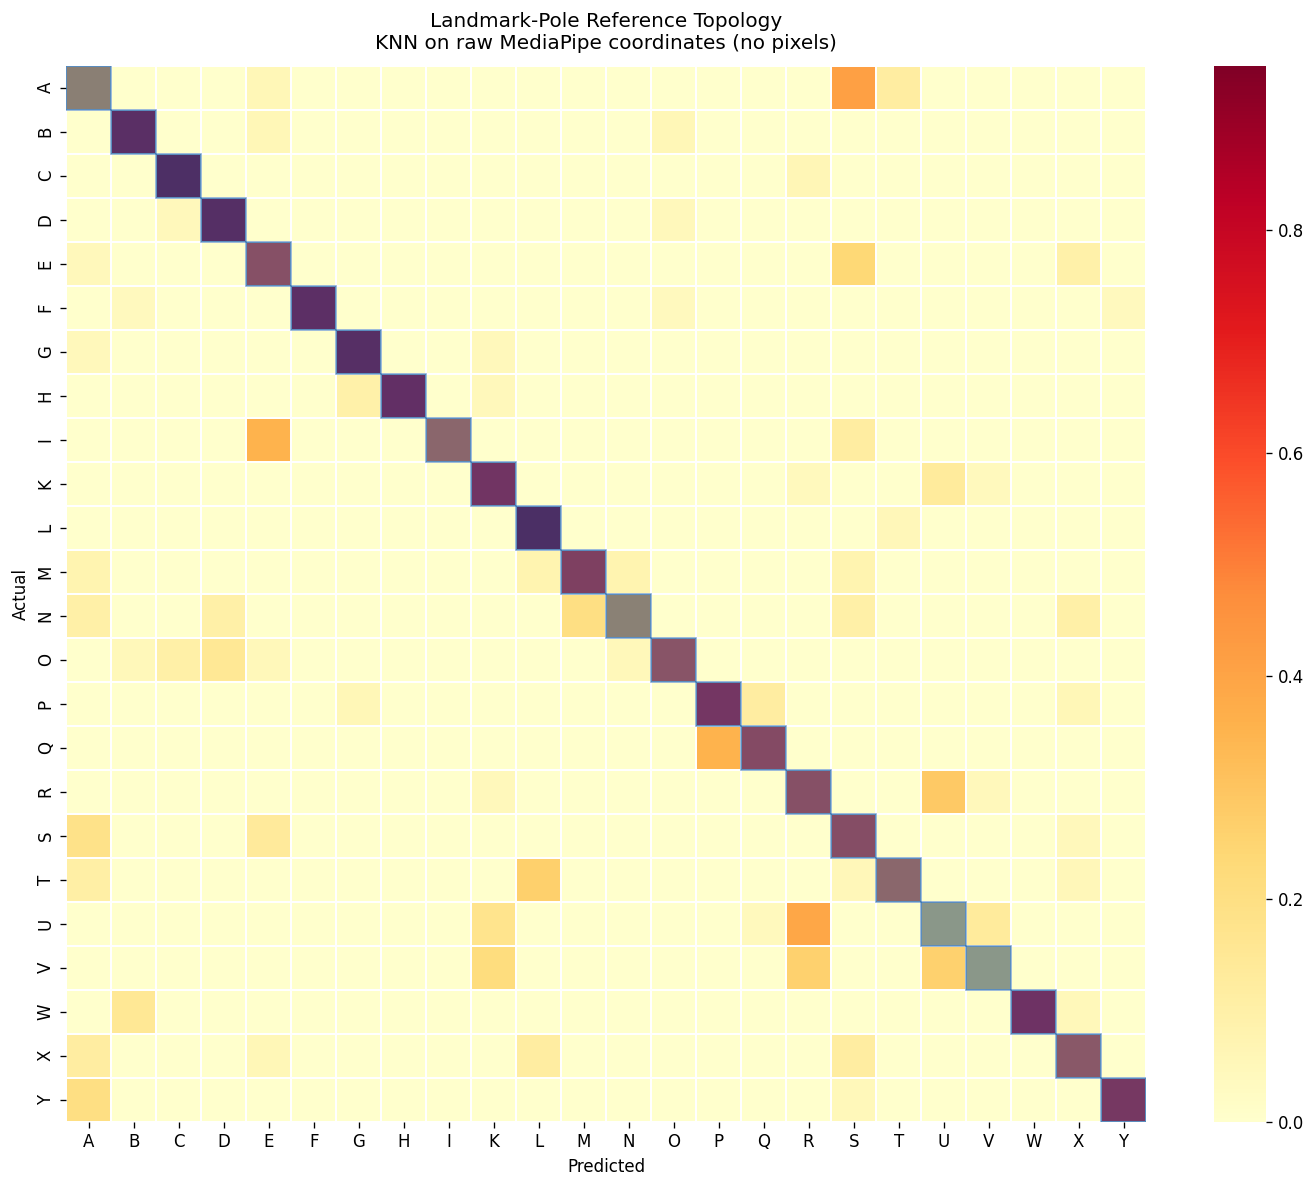

STEP 2: Vectorized Spearman Correlation
Gemma-Roboflow vs Gemma-ISL
  Type: RELIABILITY — same instrument, different datasets
  ρ = 0.7696 | p = 0.000000 ***

Gemma-Roboflow vs Landmark-Ref
  Type: PLACEMENT — Roboflow vs landmark pole
  ρ = 0.1833 | p = 0.000010 ***

Gemma-ISL vs Landmark-Ref
  Type: PLACEMENT — ISL vs landmark pole (cross-linguistic)
  ρ = 0.1780 | p = 0.000017 ***

Random baseline (permuted): ρ = -0.0172 | p = 0.679651



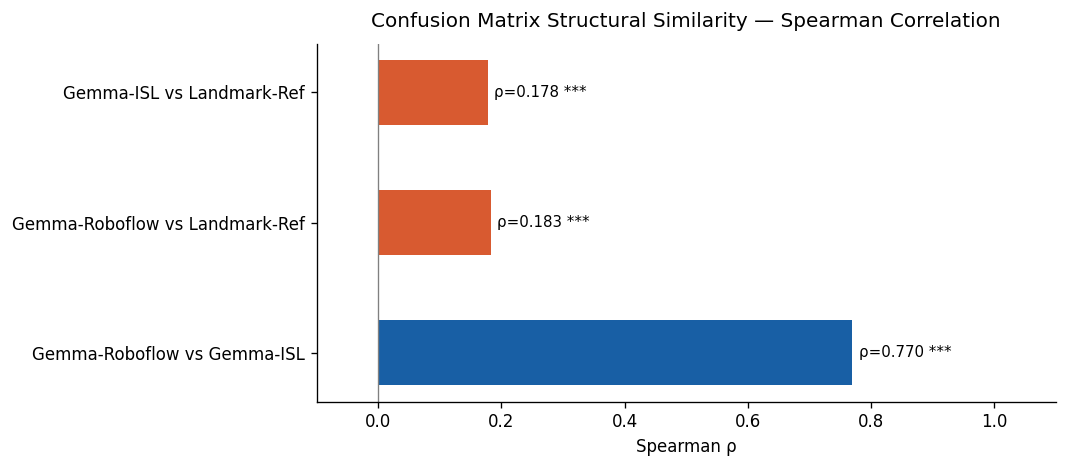

STEP 3: Asymmetry Index — Directional Signature Stability
AI stability (Spearman across datasets): ρ = 0.7753 | p = 0.000000 ***
Interpretation: STABLE — directional signature is structural

--- AI for predicted confusion pairs ---

V-family (geometric):
  K-V: AI_roboflow=0.0233 | AI_isl=0.0000
  U-V: AI_roboflow=0.1020 | AI_isl=0.0377
  R-V: AI_roboflow=0.0357 | AI_isl=0.0000
  V-W: AI_roboflow=0.1429 | AI_isl=0.2075
  V-Y: AI_roboflow=0.0000 | AI_isl=0.0000

I-family (non-geometric):
  D-I: AI_roboflow=0.5015 | AI_isl=0.4786
  I-T: AI_roboflow=0.0000 | AI_isl=0.0000
  I-X: AI_roboflow=0.0000 | AI_isl=0.0000
  G-I: AI_roboflow=0.3423 | AI_isl=0.2585

Top 15 highest-AI pairs (Roboflow):
pair  P_i_to_j  P_j_to_i     AI
 L-W    0.9756    0.0000 0.9756
 I-M    0.0333    0.5610 0.5276
 I-Y    0.0000    0.5208 0.5208
 D-I    0.6515    0.1500 0.5015
 D-G    0.0152    0.4615 0.4464
 D-U    0.0303    0.4595 0.4292
 D-Q    0.0000    0.4118 0.4118
 G-I    0.3590    0.0167 0.3423
 E-F    0.0149 

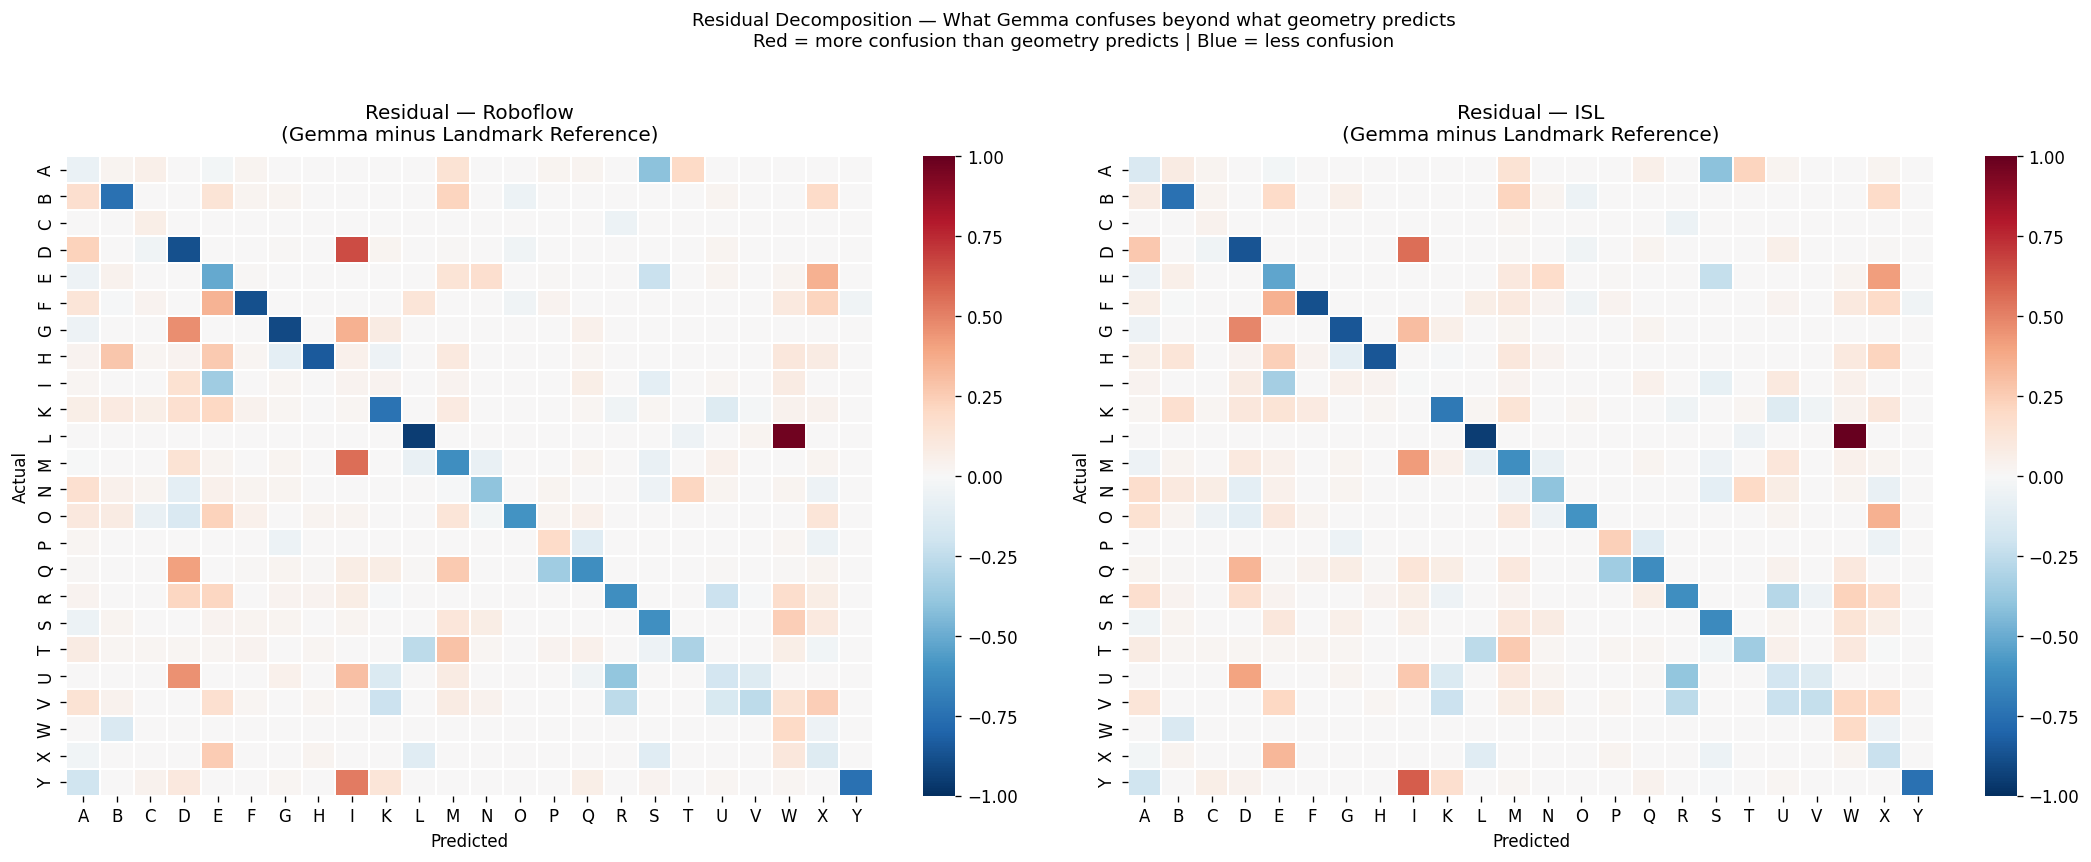

STEP 5: Bootstrap Stability
Bootstrap samples: 1000

Pair          Mean AI        Std               95% CI    Stable?
-----------------------------------------------------------------
K-V            0.0242     0.0223 [0.0000, 0.0698]          NO
D-I            0.4975     0.0739 [0.3529, 0.6379]         YES
T-I            0.0000     0.0000 [0.0000, 0.0000]         YES
X-I            0.0000     0.0000 [0.0000, 0.0000]         YES
C-O            0.0251     0.0254 [0.0000, 0.0769]          NO
M-N            0.1904     0.0608 [0.0714, 0.3095]          NO



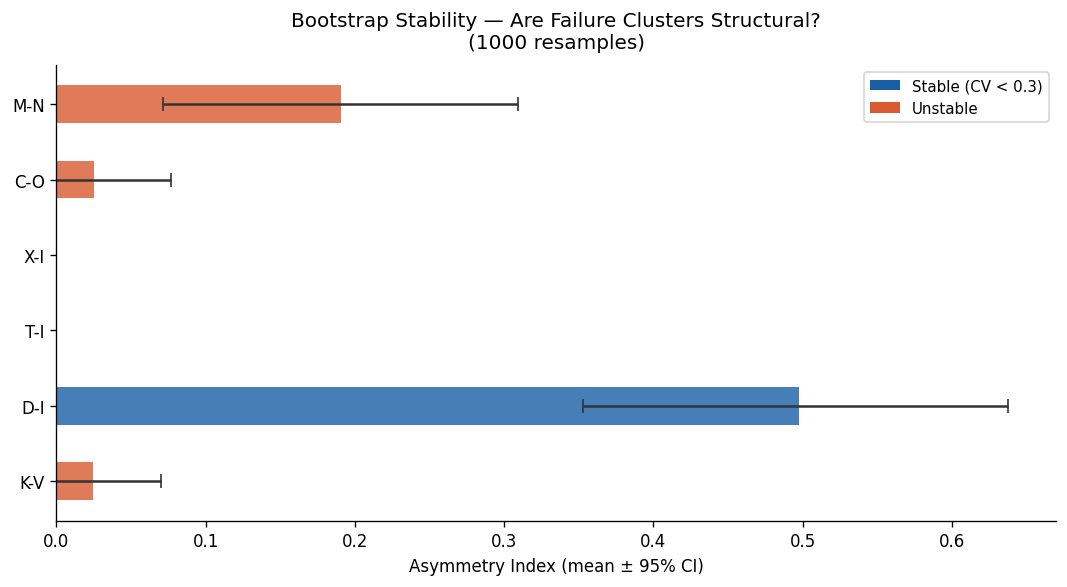

STEP 6: Row-wise Canonical Correlation
Mean per-letter ρ (Gemma-Roboflow vs Gemma-ISL):    0.7679
Mean per-letter ρ (Gemma-Roboflow vs Landmark-Ref): 0.1824

Interpretation:
  Cross-dataset consistency: HIGH
  Landmark similarity:       LOW

Top 5 most consistent letters (Roboflow vs ISL):
letter  rho_gemma_rr  rho_gemma_vs_landmark
     W        1.0000                 0.6026
     S        0.8756                 0.5397
     E        0.8702                 0.3567
     U        0.8656                 0.1449
     Y        0.8499                -0.0331

Bottom 5 least consistent letters:
letter  rho_gemma_rr  rho_gemma_vs_landmark
     D        0.6985                 0.0566
     X        0.6777                 0.5320
     O        0.6760                 0.1354
     P        0.6030                 0.2414
     R        0.5682                 0.1418


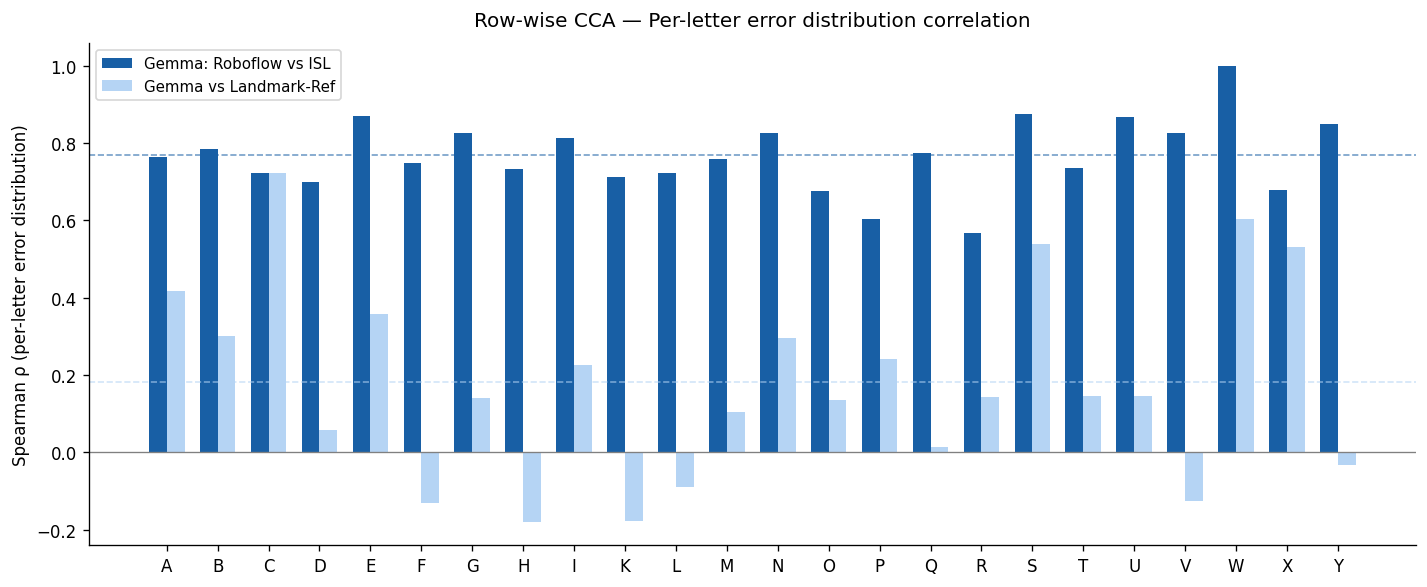


STEP 7: Directed Graph Comparison
Edge overlap (Jaccard):
  Gemma-Roboflow vs Gemma-ISL:    0.6522  — HIGH structural overlap
  Gemma-Roboflow vs Landmark-Ref: 0.0196  — LOW structural overlap

Edge weight correlation (shared edges only):
  Gemma-Roboflow vs Gemma-ISL:    ρ = 0.8473 | p = 0.0000
  Gemma-Roboflow vs Landmark-Ref: ρ = nan | p = nan

Graph sizes (edges above threshold=0.15):
  Gemma-Roboflow: 38 edges
  Gemma-ISL:      38 edges
  Landmark-Ref:   14 edges

Top error-source nodes (out-degree, Gemma-Roboflow):
  L: 0.9756
  D: 0.8788
  G: 0.8205
  B: 0.7778
  U: 0.7568
  Q: 0.6765
  N: 0.6667
  E: 0.6119


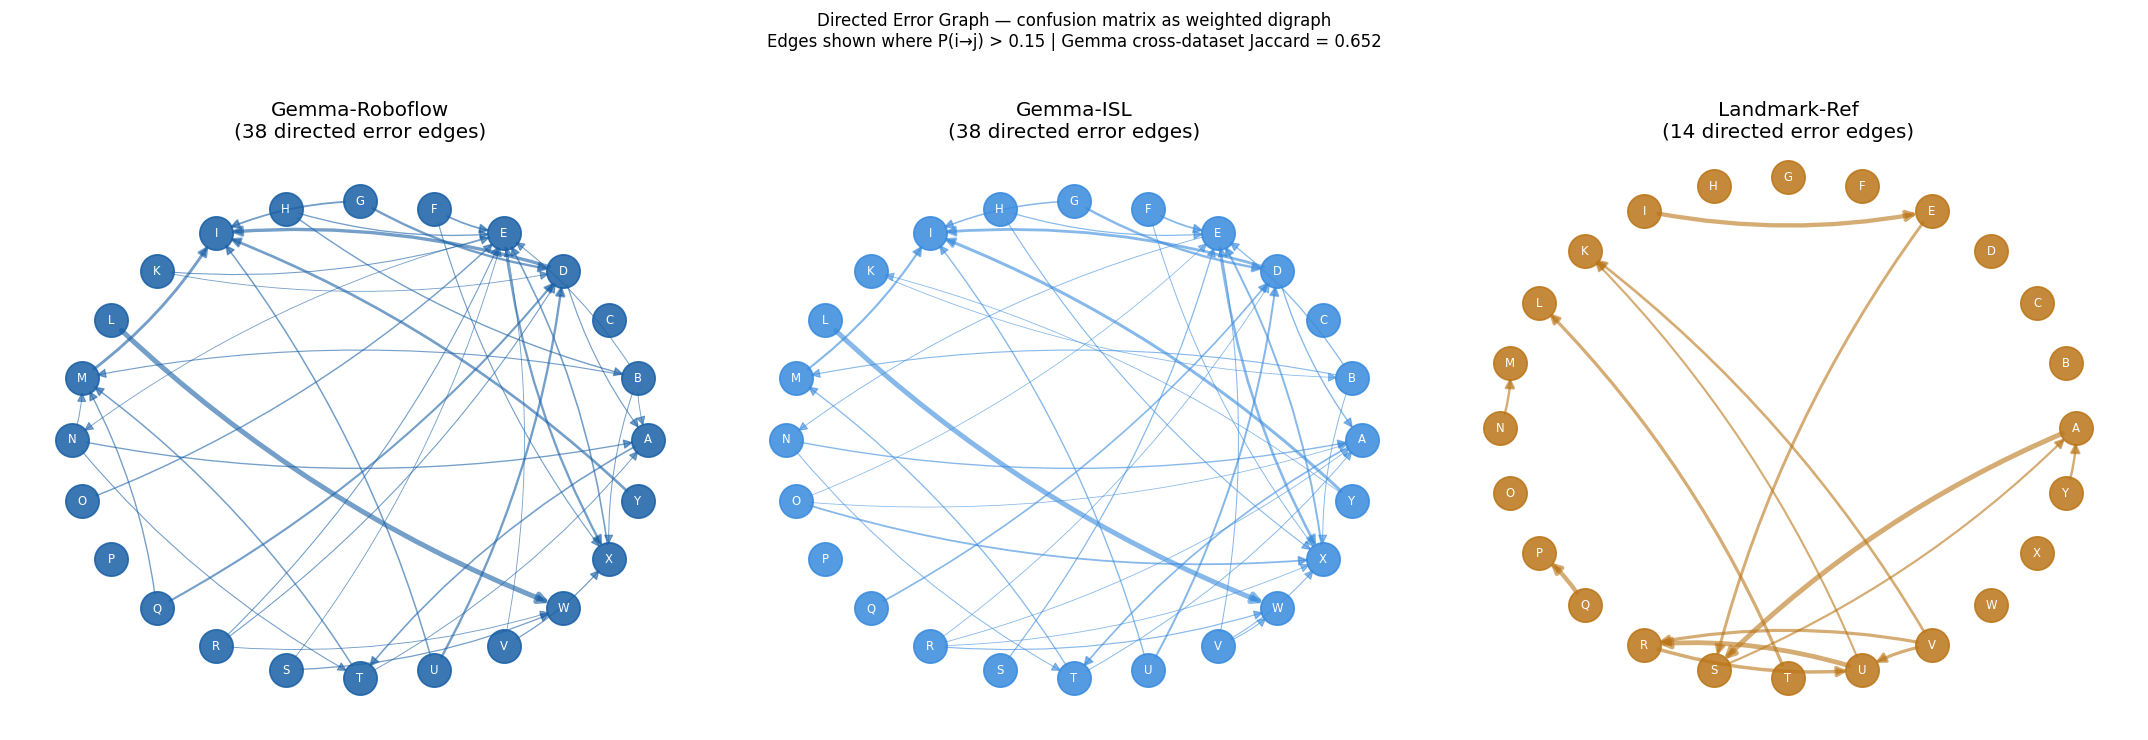



VALIDATION SUMMARY

Spearman Results:
                    Comparison  Spearman_rho  p_value
   Gemma-Roboflow vs Gemma-ISL        0.7696 0.000000
Gemma-Roboflow vs Landmark-Ref        0.1833 0.000010
     Gemma-ISL vs Landmark-Ref        0.1780 0.000017

AI Stability (Roboflow vs ISL): ρ = 0.7753

Bootstrap Stability:
pair  mean_AI stable
 K-V 0.024233     NO
 D-I 0.497456    YES
 T-I 0.000000    YES
 X-I 0.000000    YES
 C-O 0.025128     NO
 M-N 0.190405     NO

CCA — Gemma-Roboflow vs Gemma-ISL row correlation: 0.7679
CCA — Gemma-Roboflow vs Landmark-Ref row correlation: 0.1824

Graph Similarity (edge weight correlation):
  Gemma-Roboflow vs Gemma-ISL:    ρ = 0.8473
  Gemma-Roboflow vs Landmark-Ref: ρ = nan

Done. Figures saved to: /content/drive/MyDrive/ASL_Project/validation_outputs


In [ ]:
if __name__ == "__main__":
    print("\n" + "="*60)
    print("ASL DECODER RING — VALIDATION PROTOCOL")
    print("="*60 + "\n")

    # Step 1: Build landmark reference
    landmark_cm, landmark_labels = build_landmark_reference(LANDMARKS_RAW, LABELS)
    plot_landmark_reference_cm(landmark_cm, LABELS)

    # Step 2: Spearman structural similarity
    spearman_df = run_spearman_comparisons(GEMMA_ROBOFLOW, GEMMA_ISL, landmark_cm, LABELS)
    plot_spearman_results(spearman_df)

    # Step 3: Asymmetry Index
    ai_roboflow, ai_isl, ai_merged, ai_rho = run_asymmetry_analysis(GEMMA_ROBOFLOW, GEMMA_ISL, LABELS)

    # Step 4: Residual decomposition
    res_roboflow, res_isl, res_df = run_residual_analysis(GEMMA_ROBOFLOW, GEMMA_ISL, landmark_cm, LABELS)
    plot_residual_heatmaps(res_roboflow, res_isl, LABELS)

    # Step 5: Bootstrap stability
    target_pairs = [('K','V'),('D','I'),('T','I'),('X','I'),('C','O'),('M','N')]
    stability_df = bootstrap_cluster_stability(GEMMA_ROBOFLOW, LABELS, n_bootstrap=1000, target_pairs=target_pairs)
    plot_bootstrap_stability(stability_df)

    # Step 6: Row-wise Canonical Correlation
    cca_results = run_cca_analysis(GEMMA_ROBOFLOW, GEMMA_ISL, landmark_cm, LABELS)

    # Step 7: Directed Graph Comparison
    graph_results = run_directed_graph_comparison(GEMMA_ROBOFLOW, GEMMA_ISL, landmark_cm, LABELS)

    # Summary
    print("\n" + "="*60)
    print("VALIDATION SUMMARY")
    print("="*60)
    print("\nSpearman Results:")
    print(spearman_df[['Comparison','Spearman_rho','p_value']].to_string(index=False))
    print(f"\nAI Stability (Roboflow vs ISL): ρ = {ai_rho:.4f}")
    print(f"\nBootstrap Stability:")
    print(stability_df[['pair','mean_AI','stable']].to_string(index=False))
    print(f"\nCCA — Gemma-Roboflow vs Gemma-ISL row correlation: {cca_results['rr_mean']:.4f}")
    print(f"CCA — Gemma-Roboflow vs Landmark-Ref row correlation: {cca_results['rl_mean']:.4f}")
    print(f"\nGraph Similarity (edge weight correlation):")
    print(f"  Gemma-Roboflow vs Gemma-ISL:    ρ = {graph_results['rr_rho']:.4f}")
    print(f"  Gemma-Roboflow vs Landmark-Ref: ρ = {graph_results['rl_rho']:.4f}")
    print(f"\nDone. Figures saved to: {OUTPUT_DIR}")